# Implementing Many-Body Collapse Model via QuSpin

In [1]:
# Import libraries
from quspin.operators import hamiltonian, quantum_operator, quantum_LinearOperator, ishamiltonian
from quspin.basis import spin_basis_1d
from quspin.tools.measurements import ent_entropy, diag_ensemble, obs_vs_time
from quspin.tools.misc import mean_level_spacing

from joblib import Parallel, delayed
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import gaussian_kde
from tqdm import tqdm

# Set default plot parameters
plt.rcParams["font.size"] = 18
plt.rcParams["font.family"] = "Arial"

# Set random seed for reproducibility
rng = np.random.default_rng(42)

## Single pixel meltdown

In [52]:
def construct_single_pixel_hamiltonian(N_pixel, lmbda_x, lmbda_z, check_symm=False, check_herm=False):
    # Create spin basis as follows:
    # - Qubit to measure: 0
    # - Pixel: 1,...,N_pixel
    N_total = N_pixel + 1  # Pixel + single qubit
    basis = spin_basis_1d(N_total, pauli=True)

    # Define site-coupling lists
    # Free Hamiltonian of the pixel (open BC)
    Hfree = [[1.0, i, i + 1] for i in range(1, N_pixel)]

    # Interaction Hamiltonian
    Hint_x = [[lmbda_x / 2, 0, i] for i in range(1, N_total)]
    Hint_z = [[lmbda_z / 2, 0, i] for i in range(1, N_total)]
    Hext_x = [[lmbda_x / 2, i] for i in range(1, N_total)]
    Hext_z = [[lmbda_z / 2, i] for i in range(1, N_total)]

    # Define total Hamiltonian
    static = [["zz", Hfree], ["zx", Hint_x], ["zz", Hint_z], ["x", Hext_x], ["z", Hext_z]]
    H = hamiltonian(static, [], basis=basis, dtype=np.float64, check_symm=check_symm, check_herm=check_herm)

    return H, basis

In [294]:
# System parameters
N_pixel = 11  # Number of spins in pixel
lmbda_x = 1.3  # X component of qubit-pixel coupling
lmbda_z = -0.3  # Z component of qubit-pixel coupling

# Construct single-pixel Hamiltonian
H, basis = construct_single_pixel_hamiltonian(N_pixel, lmbda_x, lmbda_z)

# Perform exact diagonalization
E, V = H.eigh()
print("Exact diagonalization completed!")

Exact diagonalization completed!


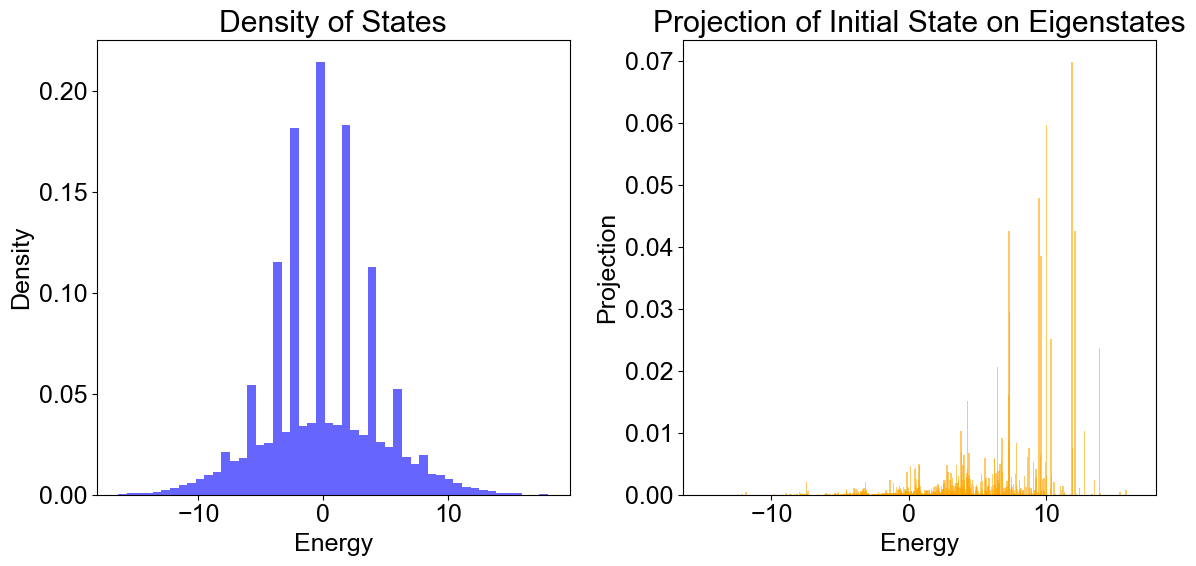

In [295]:
# Plot the density of states and projection of initial state on eigenstates
fig, axs = plt.subplots(1, 2, figsize=(12, 6), dpi=100)

# Plot density of states
axs[0].hist(E, bins=50, density=True, alpha=0.6,
            color="blue", label="Density of States")
axs[0].set_xlabel("Energy")
axs[0].set_ylabel("Density")
axs[0].set_title("Density of States")

# Plot projection of initial state on eigenstates
psi0 = np.zeros(basis.Ns, dtype=np.complex128)
psi0[0] = 1.0
proj = np.abs(np.dot(V.conj().T, psi0)) ** 2
axs[1].bar(E, proj, width=0.1, alpha=0.6,
           color="orange", label="Projection of Initial State")
axs[1].set_xlabel("Energy")
axs[1].set_ylabel("Projection")
axs[1].set_title("Projection of Initial State on Eigenstates")
axs[1].set_xlim(E.min(), E.max())

plt.tight_layout()
plt.show()

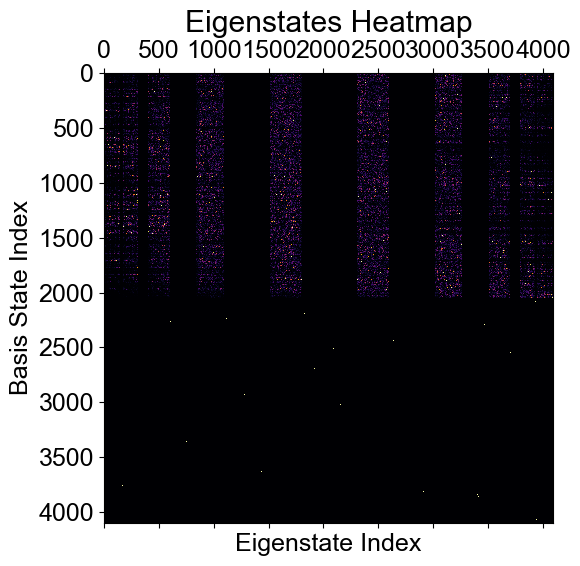

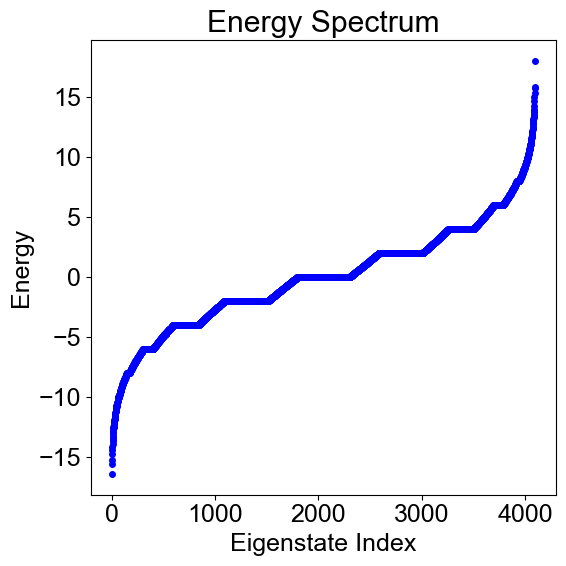

In [296]:
# Plot eigenstates as heatmap
prob = np.abs(V) ** 2
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
heatmap = ax.matshow(prob / np.max(prob, axis=0), cmap="inferno", vmin=0, vmax=1)
ax.set_xlabel("Eigenstate Index")
ax.set_ylabel("Basis State Index")
ax.set_title("Eigenstates Heatmap")
plt.tight_layout()
plt.show()

# Plot plot the energy spectrum
fig, ax = plt.subplots(figsize=(6, 6), dpi=100)
ax.plot(E, marker="o", linestyle="None", markersize=4, color="blue")
ax.set_xlabel("Eigenstate Index")
ax.set_ylabel("Energy")
ax.set_title("Energy Spectrum")
plt.tight_layout()
plt.show()

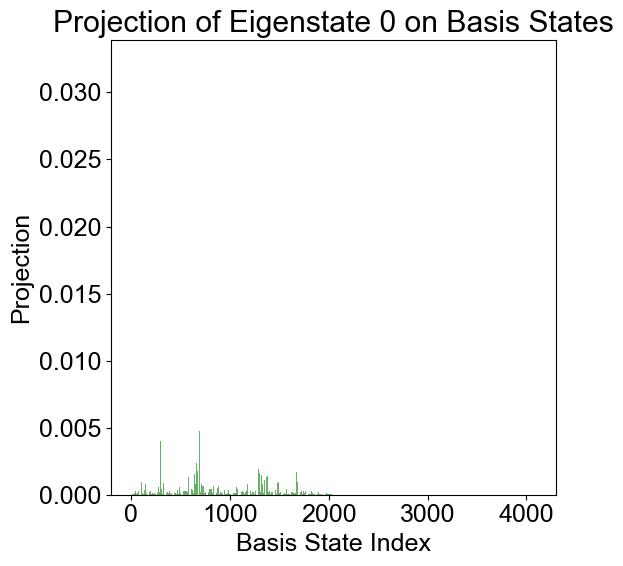

In [297]:
# Plot projection of specific eigenstate
eigenstate_index = 0
proj_eigenstate = np.abs(V[:, eigenstate_index]) ** 2
fig, ax = plt.subplots(figsize=(6, 6), dpi=100)
ax.bar(range(basis.Ns), proj_eigenstate, color="green", alpha=0.6)
ax.set_xlabel("Basis State Index")
ax.set_ylabel("Projection")
ax.set_title(f"Projection of Eigenstate {eigenstate_index} on Basis States")
plt.tight_layout()
plt.show()

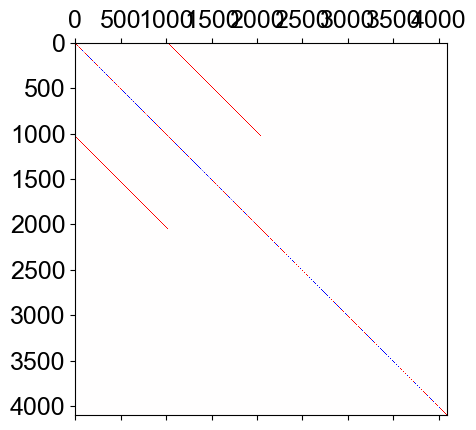

In [317]:
Hmat = H.toarray()
plt.matshow(Hmat, cmap="bwr", vmin=-1, vmax=1)
plt.show()

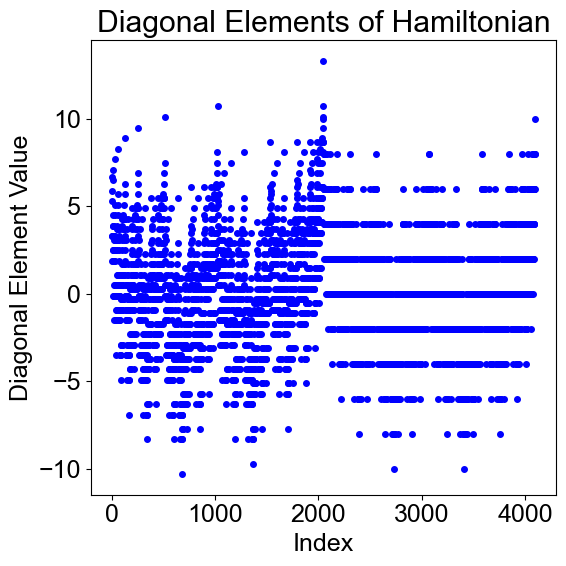

In [312]:
d = Hmat.diagonal()
fig, ax = plt.subplots(figsize=(6, 6), dpi=100)
ax.plot(d, marker="o", linestyle="None", markersize=4, color="blue")
ax.set_xlabel("Index")
ax.set_ylabel("Diagonal Element Value")
ax.set_title("Diagonal Elements of Hamiltonian")
plt.tight_layout()
plt.show()

In [299]:
# Compute time evolution of <Sx>, <Sy>, <Sz>
Sx = hamiltonian([["x", [[1 / N_pixel, i] for i in range(1, N_pixel + 1)]]], [],
                 basis=basis, dtype=np.float64, check_symm=False, check_herm=False)
Sy = hamiltonian([["y", [[1j / N_pixel, i] for i in range(1, N_pixel + 1)]]], [],
                 basis=basis, dtype=np.float64, check_symm=False, check_herm=False)
Sz = hamiltonian([["z", [[1 / N_pixel, i] for i in range(1, N_pixel + 1)]]], [],
                 basis=basis, dtype=np.float64, check_symm=False, check_herm=False)

times = np.linspace(0, 20, 1001)

psi0 = np.zeros(basis.Ns, dtype=np.complex128)
psi0[0] = 1.  # Initial state: qubit in |0>

obs_time = obs_vs_time(psi_t=(psi0, E, V), Obs_dict={"Sx": Sx, "Sy": Sy, "Sz": Sz}, times=times, verbose=True)
obs_time["Sy"] *= -1j # Convert to real-valued observable

# Remove spurious imaginary components
for obs in obs_time:
    obs_time[obs] = np.real(obs_time[obs])

obs_vs_time integrated to t=0.0200
obs_vs_time integrated to t=0.0400
obs_vs_time integrated to t=0.0600
obs_vs_time integrated to t=0.0800
obs_vs_time integrated to t=0.1000
obs_vs_time integrated to t=0.1200
obs_vs_time integrated to t=0.1400
obs_vs_time integrated to t=0.1600
obs_vs_time integrated to t=0.1800
obs_vs_time integrated to t=0.2000
obs_vs_time integrated to t=0.2200
obs_vs_time integrated to t=0.2400
obs_vs_time integrated to t=0.2600
obs_vs_time integrated to t=0.2800
obs_vs_time integrated to t=0.3000
obs_vs_time integrated to t=0.3200
obs_vs_time integrated to t=0.3400
obs_vs_time integrated to t=0.3600
obs_vs_time integrated to t=0.3800
obs_vs_time integrated to t=0.4000
obs_vs_time integrated to t=0.4200
obs_vs_time integrated to t=0.4400
obs_vs_time integrated to t=0.4600
obs_vs_time integrated to t=0.4800
obs_vs_time integrated to t=0.5000
obs_vs_time integrated to t=0.5200
obs_vs_time integrated to t=0.5400
obs_vs_time integrated to t=0.5600
obs_vs_time integrat

C:\Users\matan\AppData\Local\Temp\ipykernel_16848\3741920386.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


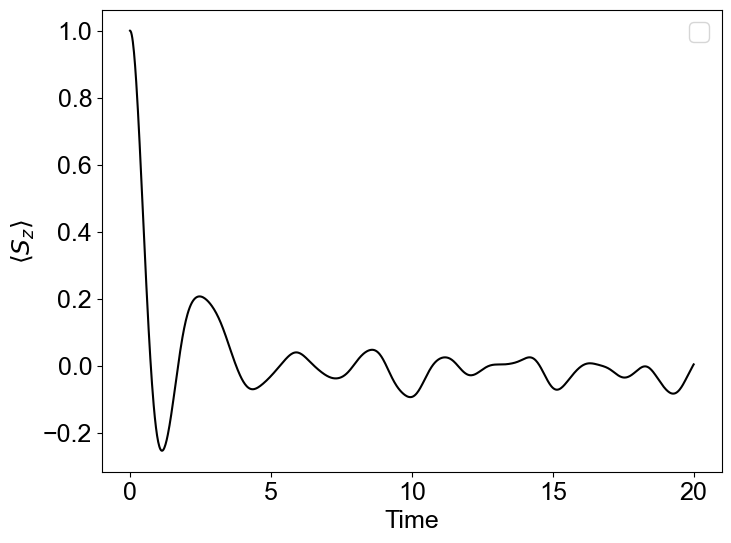

Average magnetization values:
<Sx> = 0.2742
<Sy> = -0.0191
<Sz> = 0.0146


In [300]:
# Visualize time evolution of <Sz>
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
# ax.plot(times, obs_time["Sx"], label="<Sx>")
# ax.plot(times, obs_time["Sy"], label="<Sy>")
ax.plot(times, obs_time["Sz"], color="k")
ax.set_xlabel("Time")
ax.set_ylabel(r"$\langle S_z \rangle$")
# ax.set_title("Qubit initially in |1>")
ax.legend()
plt.show()

# Print average magnetization values
print("Average magnetization values:")
print(f"<Sx> = {np.mean(obs_time['Sx']):.4f}")
print(f"<Sy> = {np.mean(obs_time['Sy']):.4f}")
print(f"<Sz> = {np.mean(obs_time['Sz']):.4f}")

In [104]:
# Compute limiting value of <Sz> (equivalent to diagonal ensemble average) for a range of lmbda, theta
N_pixel = 5
lmbda_xs = np.linspace(0., 5.0, 101)
lmbda_zs = np.linspace(-5.0, 5.0, 101)
Sz_diag = np.zeros((len(lmbda_xs), len(lmbda_zs)))

for i, lmbda_x in enumerate(tqdm(lmbda_xs)):
    for j, lmbda_z in enumerate(lmbda_zs):
        # Construct single-pixel Hamiltonian
        H, basis = construct_single_pixel_hamiltonian(N_pixel, lmbda_x, lmbda_z, check_symm=False, check_herm=False)

        # Perform exact diagonalization
        E, V = H.eigh()

        # Add small random noise to eigenvalues to avoid degeneracy
        E += np.random.normal(0, 1e-7, size=E.shape)

        # Compute Sz observable
        Sz = hamiltonian([["z", [[1 / N_pixel, i] for i in range(1, N_pixel + 1)]]], [],
                         basis=basis, dtype=np.float64, check_symm=False, check_herm=False)

        # Set initial state: qubit in |0>
        psi0 = np.zeros(basis.Ns, dtype=np.complex128)
        psi0[0] = 1.

        # Compute diagonal ensemble average
        N_total = N_pixel + 1
        Sz_diag[i, j] = N_total * diag_ensemble(N_total, psi0, E2=E, V2=V, Obs=Sz)["Obs_pure"]

100%|██████████| 101/101 [02:16<00:00,  1.36s/it]


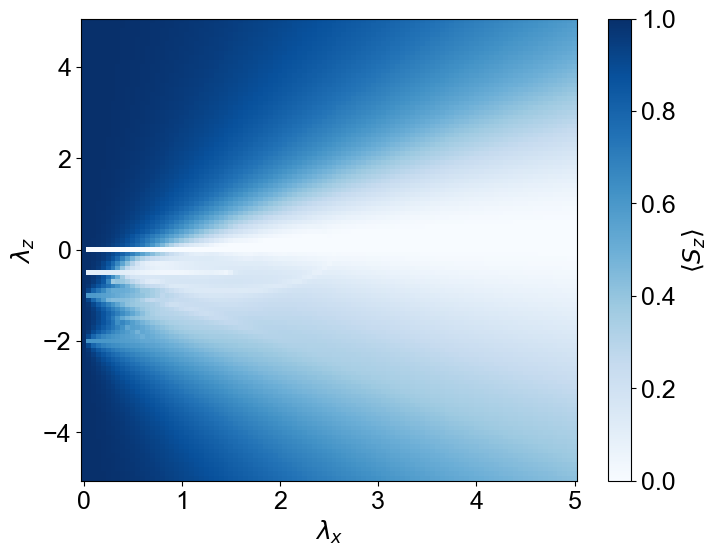

In [105]:
# Visualize 2D phase diagram
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
c = ax.pcolormesh(lmbda_xs, lmbda_zs, Sz_diag.T, shading="auto", cmap="Blues", vmin=0, vmax=1)
ax.set_xlabel(r"$\lambda_x$")
ax.set_ylabel(r"$\lambda_z$")
fig.colorbar(c, ax=ax, label=r"$\langle S_z \rangle$")
plt.show()

In [ ]:
Sz_diag[0, 0]

np.float64(0.9999999999999996)

## Two pixel meltdown

In [2]:
def construct_two_pixel_hamiltonian(N_pixel, lmbda_x, lmbda_z, lmbda0, check_symm=False, check_herm=False):
    # Create spin basis as follows:
    # - Qubit to measure: 0
    # - 1st pixel: 1,...,N_pixel
    # - 2nd pixel: N_pixel+1,...,2*N_pixel
    N_total = 2 * N_pixel + 1  # 2 pixels + single qubit
    basis = spin_basis_1d(N_total, pauli=True)

    # Define site-coupling lists
    # Free Hamiltonian of each pixel (open BC)
    H1 = [[1.0, i, i + 1] for i in range(1, N_pixel)]
    H2 = [[1.0, i, i + 1] for i in range(N_pixel + 1, N_total - 1)]

    # Interaction Hamiltonian
    Hlatch_zx1 = [[lmbda_x / 2, 0, i] for i in range(1, N_pixel + 1)]
    Hlatch_zx2 = [[-lmbda_x / 2, 0, i] for i in range(N_pixel + 1, N_total)]
    Hlatch_zz1 = [[lmbda_z / 2, 0, i] for i in range(1, N_pixel + 1)]
    Hlatch_zz2 = [[-lmbda_z / 2, 0, i] for i in range(N_pixel + 1, N_total)]
    Hlatch_x = [[lmbda_x / 2, i] for i in range(1, N_total)]
    Hlatch_z = [[lmbda_z / 2, i] for i in range(1, N_total)]
    Hback_xz1 = [[lmbda0, 0, i] for i in range(1, N_pixel + 1)]
    Hback_xz2 = [[lmbda0, 0, i] for i in range(N_pixel + 1, N_total)]
    # Hback_xx1 = [[lmbda0, 0, i] for i in range(1, N_pixel + 1)]
    # Hback_xx2 = [[lmbda0, 0, i] for i in range(N_pixel + 1, N_total)]
    # Hback_yy1 = [[lmbda0, 0, i] for i in range(1, N_pixel + 1)]
    # Hback_yy2 = [[-lmbda0, 0, i] for i in range(N_pixel + 1, N_total)]
    # Hback_zz1 = [[lmbda0, 0, i] for i in range(1, N_pixel + 1)]
    # Hback_zz2 = [[-lmbda0, 0, i] for i in range(N_pixel + 1, N_total)]

    # Define total Hamiltonian
    static = [["zz", H1], ["zz", H2], ["zx", Hlatch_zx1], ["zx", Hlatch_zx2],
              ["zz", Hlatch_zz1], ["zz", Hlatch_zz2], ["x", Hlatch_x], ["z", Hlatch_z],
              ["xz", Hback_xz1], ["xz", Hback_xz2]]
              # ["xx", Hback_xx1], ["xx", Hback_xx2], ["yy", Hback_yy1], ["yy", Hback_yy2], ["zz", Hback_zz1], ["zz", Hback_zz2]]
    H = hamiltonian(static, [], basis=basis, dtype=np.float64, check_symm=check_symm, check_herm=check_herm)
    return H, basis

In [324]:
N_pixel = 5  # Number of spins in pixel
N_total = 2 * N_pixel + 1  # 2 pixels + single qubit
lmbda_x = 1.  # X component of qubit-pixel coupling
lmbda_z = 0.  # Z component of qubit-pixel coupling
lmbda0 = 0*0.1 / N_pixel  # Inter-pixel coupling strength

# Construct two-pixel Hamiltonian
H, basis = construct_two_pixel_hamiltonian(N_pixel, lmbda_x, lmbda_z, lmbda0)

In [325]:
# Perform exact diagonalization
E, V = H.eigh()
print("Exact diagonalization completed!")

Exact diagonalization completed!


In [3]:
def time_evolution_average_spin(N_pixel, E, V, basis, times, psi0):
    N_total = 2 * N_pixel + 1  # 2 pixels + single qubit

    # Average spin observables
    obs_dict = {
        "Sx0": hamiltonian([["x", [[1, 0]]]], [],
                           basis=basis, dtype=np.float64, check_symm=False, check_herm=False),
        "Sy0": hamiltonian([["y", [[1j, 0]]]], [],
                           basis=basis, dtype=np.float64, check_symm=False, check_herm=False),
        "Sz0": hamiltonian([["z", [[1, 0]]]], [],
                           basis=basis, dtype=np.float64, check_symm=False, check_herm=False),

        "Sx1": hamiltonian([["x", [[1 / N_pixel, i] for i in range(1, N_pixel + 1)]]], [],
                           basis=basis, dtype=np.float64, check_symm=False, check_herm=False),
        "Sy1": hamiltonian([["y", [[1j / N_pixel, i] for i in range(1, N_pixel + 1)]]], [],
                           basis=basis, dtype=np.float64, check_symm=False, check_herm=False),
        "Sz1": hamiltonian([["z", [[1 / N_pixel, i] for i in range(1, N_pixel + 1)]]], [],
                           basis=basis, dtype=np.float64, check_symm=False, check_herm=False),

        "Sx2": hamiltonian([["x", [[1 / N_pixel, i] for i in range(N_pixel + 1, N_total)]]], [],
                           basis=basis, dtype=np.float64, check_symm=False, check_herm=False),
        "Sy2": hamiltonian([["y", [[1j / N_pixel, i] for i in range(N_pixel + 1, N_total)]]], [],
                           basis=basis, dtype=np.float64, check_symm=False, check_herm=False),
        "Sz2": hamiltonian([["z", [[1 / N_pixel, i] for i in range(N_pixel + 1, N_total)]]], [],
                           basis=basis, dtype=np.float64, check_symm=False, check_herm=False)
    }

    # Compute time evolution of average Sz
    obs_time = obs_vs_time(psi_t=(psi0, E, V), Obs_dict=obs_dict, Sent_args={
                           "basis": basis, "sub_sys_A": list(range(N_pixel + 1)), "density": False}, times=times)

    # Convert the Sy observables back to real-valued observables
    for obs in ["Sy0", "Sy1", "Sy2"]:
        obs_time[obs] *= -1j

    # Remove spurious imaginary components
    for obs in obs_dict.keys():
        obs_time[obs] = np.real(obs_time[obs])

    return obs_time

In [126]:
N_pixel = 5  # Number of spins in pixel
N_total = 2 * N_pixel + 1  # 2 pixels + single qubit
lmbda_x = 1.3  # X component of qubit-pixel coupling
lmbda_z = -0.3  # Z component of qubit-pixel coupling
lmbda0 = 0. / N_pixel  # Inter-pixel coupling strength

# Construct two-pixel Hamiltonian
H, basis = construct_two_pixel_hamiltonian(N_pixel, lmbda_x, lmbda_z, lmbda0)

# Perform exact diagonalization
E, V = H.eigh()
print("Exact diagonalization completed!")

Exact diagonalization completed!


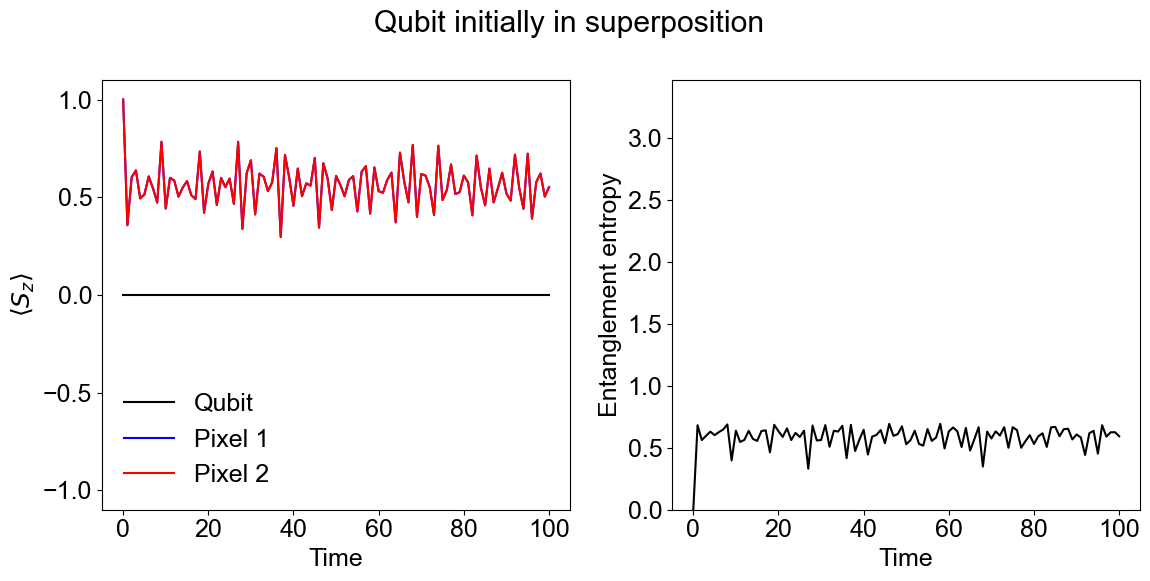

In [127]:
# Compute time evolution of <Sz> in the qubit and in each pixel for various initial states

# Average Sz observables
times = np.linspace(0, 100, 101)

# # Qubit in |0>
# psi0 = np.zeros(basis.Ns, dtype=np.complex128)
# psi0[0] = 1.
# obs_time = time_evolution_average_spin(N_pixel, E, V, basis, times, psi0)

# fig, axs = plt.subplots(1, 2, figsize=(12, 6))
# axs[0].plot(times, obs_time["Sz0"], label="Qubit", color="black")
# axs[0].plot(times, obs_time["Sz1"], label="Pixel 1", color="blue")
# axs[0].plot(times, obs_time["Sz2"], label="Pixel 2", color="red")
# axs[0].set_ylim(-1.1, 1.1)
# axs[0].set_xlabel("Time")
# axs[0].set_ylabel("$\\langle S_z \\rangle$")
# axs[0].legend(frameon=False)
# axs[1].plot(times, obs_time["Sent_time"]["Sent_A"], color="black")
# axs[1].set_xlabel("Time")
# axs[1].set_ylabel("Entanglement entropy")
# axs[1].set_ylim(0, N_pixel * np.log(2))
# fig.suptitle("Qubit initially in |0>")
# plt.tight_layout()
# plt.show()

# # Qubit in |1>
# psi0 = np.zeros(basis.Ns, dtype=np.complex128)
# psi0[basis.Ns // 2] = 1.
# obs_time = time_evolution_average_spin(N_pixel, E, V, basis, times, psi0)

# fig, axs = plt.subplots(1, 2, figsize=(12, 6))
# axs[0].plot(times, obs_time["Sz0"], label="Qubit", color="black")
# axs[0].plot(times, obs_time["Sz1"], label="Pixel 1", color="blue")
# axs[0].plot(times, obs_time["Sz2"], label="Pixel 2", color="red")
# axs[0].set_ylim(-1.1, 1.1)
# axs[0].set_xlabel("Time")
# axs[0].set_ylabel("$\\langle S_z \\rangle$")
# axs[0].legend(frameon=False)
# axs[1].plot(times, obs_time["Sent_time"]["Sent_A"], color="black")
# axs[1].set_xlabel("Time")
# axs[1].set_ylabel("Entanglement entropy")
# axs[1].set_ylim(0, N_pixel * np.log(2))
# fig.suptitle("Qubit initially in |1>")
# plt.tight_layout()
# plt.show()

# Qubit in sqrt(0.45)|0> + sqrt(0.55)|1>
psi0 = np.zeros(basis.Ns, dtype=np.complex128)
psi0[0] = np.sqrt(0.5)
psi0[basis.Ns // 2] = np.sqrt(0.5)
obs_time = time_evolution_average_spin(N_pixel, E, V, basis, times, psi0)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].plot(times, obs_time["Sz0"], label="Qubit", color="black")
axs[0].plot(times, obs_time["Sz1"], label="Pixel 1", color="blue")
axs[0].plot(times, obs_time["Sz2"], label="Pixel 2", color="red")
axs[0].set_ylim(-1.1, 1.1)
axs[0].set_xlabel("Time")
axs[0].set_ylabel("$\\langle S_z \\rangle$")
axs[0].legend(frameon=False)
axs[1].plot(times, obs_time["Sent_time"]["Sent_A"], color="black")
axs[1].set_xlabel("Time")
axs[1].set_ylabel("Entanglement entropy")
axs[1].set_ylim(0, N_pixel * np.log(2))
fig.suptitle("Qubit initially in superposition")
plt.tight_layout()
plt.show()

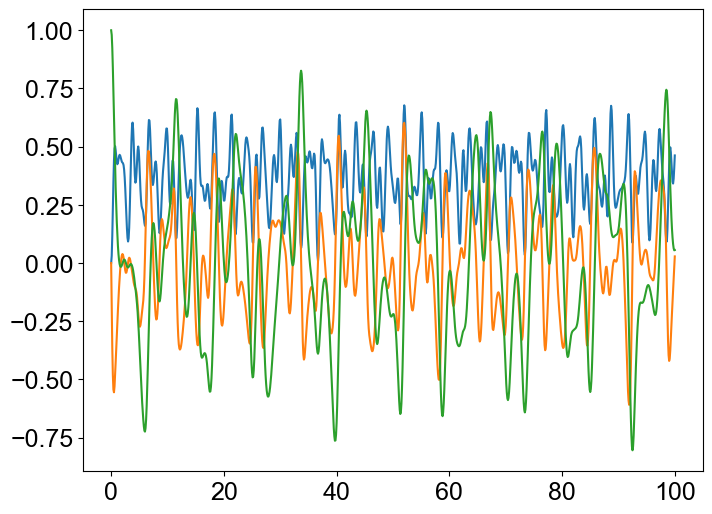

In [380]:
times = np.linspace(0, 100, 1001)

# Qubit in |0>
psi0 = np.zeros(basis.Ns, dtype=np.complex128)
psi0[0] = 1.
obs_time = time_evolution_average_spin(N_pixel, E, V, basis, times, psi0)

# Visualize the evolution of the magnetization vector (Sx, Sy, Sz)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(times, obs_time["Sx1"], label="Qubit Sx", color="C0")
ax.plot(times, obs_time["Sy1"], label="Qubit Sy", color="C1")
ax.plot(times, obs_time["Sz1"], label="Qubit Sz", color="C2")
plt.show()

In [381]:
# Mean values of Sx, Sy, Sz for qubit and two pixels
mean_Sx0 = np.mean(obs_time["Sx0"])
mean_Sy0 = np.mean(obs_time["Sy0"])
mean_Sz0 = np.mean(obs_time["Sz0"])
mean_Sx1 = np.mean(obs_time["Sx1"])
mean_Sy1 = np.mean(obs_time["Sy1"])
mean_Sz1 = np.mean(obs_time["Sz1"])
mean_Sx2 = np.mean(obs_time["Sx2"])
mean_Sy2 = np.mean(obs_time["Sy2"])
mean_Sz2 = np.mean(obs_time["Sz2"])


print(f"{'Label':8} | {'Sx':>8} | {'Sy':>8} | {'Sz':>8}")
print("-" * 42)
print(f"{'Qubit':8} | {mean_Sx0:8.5f} | {mean_Sy0:8.5f} | {mean_Sz0:8.5f}")
print(f"{'Pixel 1':8} | {mean_Sx1:8.5f} | {mean_Sy1:8.5f} | {mean_Sz1:8.5f}")
print(f"{'Pixel 2':8} | {mean_Sx2:8.5f} | {mean_Sy2:8.5f} | {mean_Sz2:8.5f}")

Label    |       Sx |       Sy |       Sz
------------------------------------------
Qubit    |  0.00000 |  0.00000 |  1.00000
Pixel 1  |  0.36331 | -0.00468 |  0.00401
Pixel 2  | -0.00000 | -0.00000 |  1.00000


## Backward Propagation

In [7]:
def generate_single_melted_pixel_state(N_pixel, qubit_state, seed=None):
    N_total = 2 * N_pixel + 1  # 2 pixels + single qubit
    N_basis_total = 2 ** N_total  # Total number of basis states
    N_basis_pixel = 2 ** N_pixel  # Number of basis states for a single pixel
    psi = np.zeros((N_basis_total,), dtype=np.complex128)

    # Initialize random number generator if not provided
    rng = np.random.default_rng(
        seed) if seed is not None else np.random.default_rng()

    # Generate random complex amplitudes for the qubit + pixel spins
    pixel_amplitudes = (rng.normal(loc=0, scale=1, size=2 * N_basis_pixel)
                        + 1j * rng.normal(loc=0, scale=1, size=2 * N_basis_pixel))
    # Normalize amplitudes
    pixel_amplitudes /= np.linalg.norm(pixel_amplitudes)

    # "blue" pixel melted down, "red" pixel in ground state
    if qubit_state == 1:
        psi[::N_basis_pixel] = pixel_amplitudes

    # "blue" pixel in ground state, "red" pixel melted down
    elif qubit_state == 0:
        psi[:N_basis_pixel] = pixel_amplitudes[:N_basis_pixel]
        psi[N_basis_total // 2:N_basis_total // 2 +
            N_basis_pixel] = pixel_amplitudes[N_basis_pixel:]
    else:
        raise ValueError("Invalid qubit state. Must be 0 or 1.")

    return psi

In [268]:
# Pauli matrices
pauli_x = np.array([[0, 1], [1, 0]])
pauli_y = np.array([[0, -1j], [1j, 0]])
pauli_z = np.array([[1, 0], [0, -1]])

# Check distribution of initial states
rs_blue, rs_red = [], []
us_blue, us_red = [], []
phis_blue, phis_red = [], []

for _ in tqdm(range(10 ** 5)):
    psi_blue = generate_single_melted_pixel_state(N_pixel, qubit_state=0, seed=None)
    psi_red = generate_single_melted_pixel_state(N_pixel, qubit_state=1, seed=None)

    psi_blue_rdm = basis.partial_trace(psi_blue, sub_sys_A=[0])
    psi_red_rdm = basis.partial_trace(psi_red, sub_sys_A=[0])

    sx_blue = np.real(np.trace(pauli_x @ psi_blue_rdm))
    sx_red = np.real(np.trace(pauli_x @ psi_red_rdm))
    sy_blue = np.real(np.trace(pauli_y @ psi_blue_rdm))
    sy_red = np.real(np.trace(pauli_y @ psi_red_rdm))
    sz_blue = np.real(np.trace(pauli_z @ psi_blue_rdm))
    sz_red = np.real(np.trace(pauli_z @ psi_red_rdm))

    r_blue = np.sqrt(sx_blue ** 2 + sy_blue ** 2 + sz_blue ** 2)
    r_red = np.sqrt(sx_red ** 2 + sy_red ** 2 + sz_red ** 2)
    u_blue = sz_blue / r_blue if r_blue != 0 else 0
    u_red = sz_red / r_red if r_red != 0 else 0
    phi_blue = np.arctan2(sy_blue, sx_blue) if r_blue != 0 else 0
    phi_red = np.arctan2(sy_red, sx_red) if r_red != 0 else 0

    rs_blue.append(r_blue)
    rs_red.append(r_red)
    us_blue.append(u_blue)
    us_red.append(u_red)
    phis_blue.append(phi_blue)
    phis_red.append(phi_red)

100%|██████████| 100000/100000 [02:59<00:00, 556.17it/s]


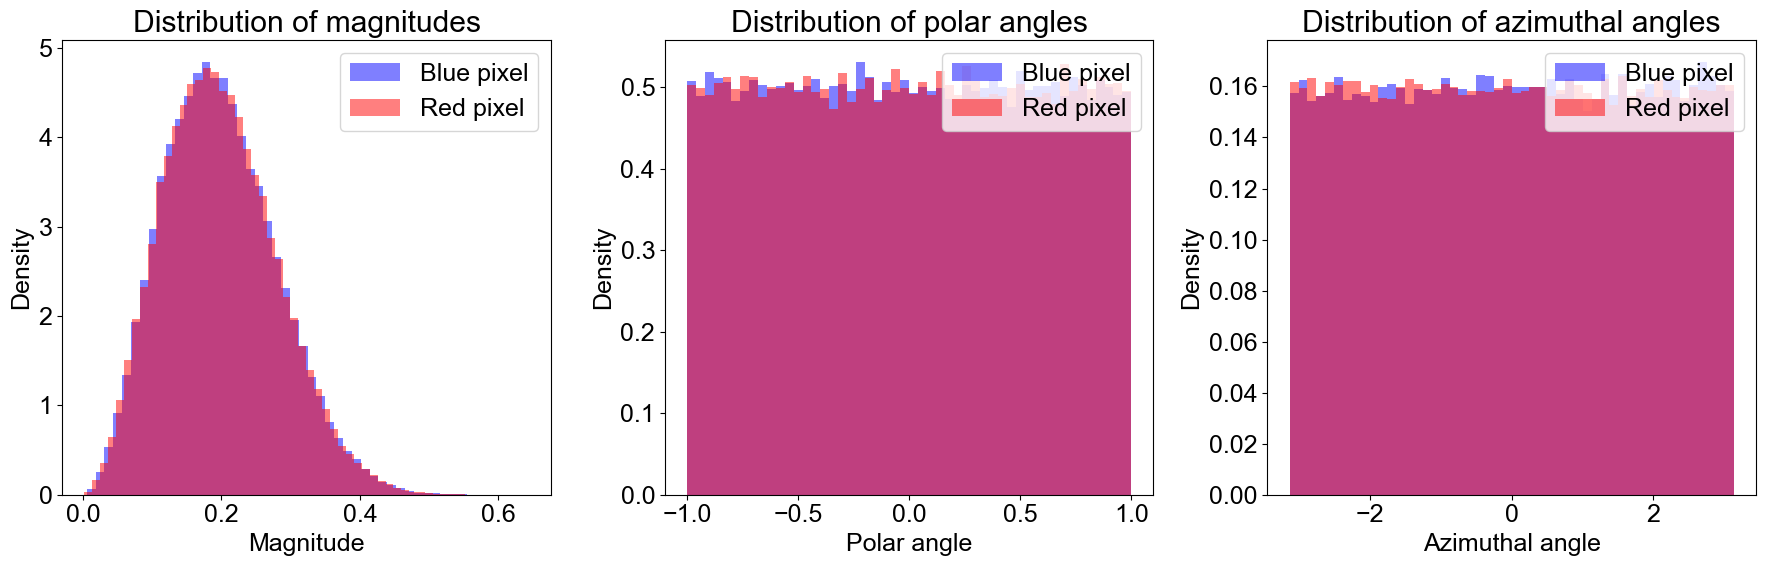

In [269]:
# Visualize distributions

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
axs[0].hist(rs_blue, bins=50, density=True, alpha=0.5, label="Blue pixel", color="blue")
axs[0].hist(rs_red, bins=50, density=True, alpha=0.5, label="Red pixel", color="red")
axs[0].set_xlabel("Magnitude")
axs[0].set_ylabel("Density")
axs[0].set_title("Distribution of magnitudes")
axs[0].legend()

axs[1].hist(us_blue, bins=50, density=True, alpha=0.5, label="Blue pixel", color="blue")
axs[1].hist(us_red, bins=50, density=True, alpha=0.5, label="Red pixel", color="red")
axs[1].set_xlabel("Polar angle")
axs[1].set_ylabel("Density")
axs[1].set_title("Distribution of polar angles")
axs[1].legend()

axs[2].hist(phis_blue, bins=50, density=True, alpha=0.5, label="Blue pixel", color="blue")
axs[2].hist(phis_red, bins=50, density=True, alpha=0.5, label="Red pixel", color="red")
axs[2].set_xlabel("Azimuthal angle")
axs[2].set_ylabel("Density")
axs[2].set_title("Distribution of azimuthal angles")
axs[2].legend()

plt.tight_layout()
plt.show()

In [69]:
# System parameters
N_pixel = 3  # Number of spins in pixel
lmbda_x = 1.3  # X component of qubit-pixel coupling
lmbda_z = -0.3  # Z component of qubit-pixel coupling
lmbda0 = 1.0 / N_pixel  # Inter-pixel coupling strength
# times = np.linspace(0, 40, 41)  # Time points for evolution
times = [1e6]

# Construct two-pixel Hamiltonian
H, basis = construct_two_pixel_hamiltonian(N_pixel, lmbda_x, lmbda_z, lmbda0)

In [70]:
# Perform exact diagonalization
E, V = H.eigh()
print("Exact diagonalization completed!")

Exact diagonalization completed!


In [71]:
# Simulate time evolution for one of the pixel melted states
def simulate_melted_pixel_state(qubit_state, E, V, basis, times, seed=None):
    psi0 = generate_single_melted_pixel_state(N_pixel, qubit_state=qubit_state, seed=seed)
    obs_time = time_evolution_average_spin(N_pixel, E, V, basis, times, psi0)
    return obs_time


# Compute time evolution in parallel
realizations = 10 ** 4

obs_time_blue = Parallel(n_jobs=4, verbose=10)(
    delayed(simulate_melted_pixel_state)(
        qubit_state=1, E=E, V=V, basis=basis, times=times, seed=i
    ) for i in range(realizations))
obs_time_red = Parallel(n_jobs=4, verbose=10)(
    delayed(simulate_melted_pixel_state)(
        qubit_state=0, E=E, V=V, basis=basis, times=times, seed=realizations + i
    ) for i in range(realizations))

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:    2.6s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:    2.6s
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:    2.6s
[Parallel(n_jobs=4)]: Batch computation too fast (0.17573192066419582s.) Setting batch_size=2.
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:    2.7s
[Parallel(n_jobs=4)]: Batch computation too fast (0.017046689987182617s.) Setting batch_size=4.
[Parallel(n_jobs=4)]: Done  38 tasks      | elapsed:    2.7s
[Parallel(n_jobs=4)]: Batch computation too fast (0.04722785949707031s.) Setting batch_size=8.
[Parallel(n_jobs=4)]: Done  68 tasks      | elapsed:    2.8s
[Parallel(n_jobs=4)]: Batch computation too fast (0.08086848258972168s.) Setting batch_size=16.
[Parallel(n_jobs=4)]: Done 156 tasks      | elapsed:    3.1s
[Parallel(n_jobs=4)]: Done 332 tasks      | elapsed:    4.0s
[Parallel(n_jobs=4)]: Done 540 tasks      | elapsed:   

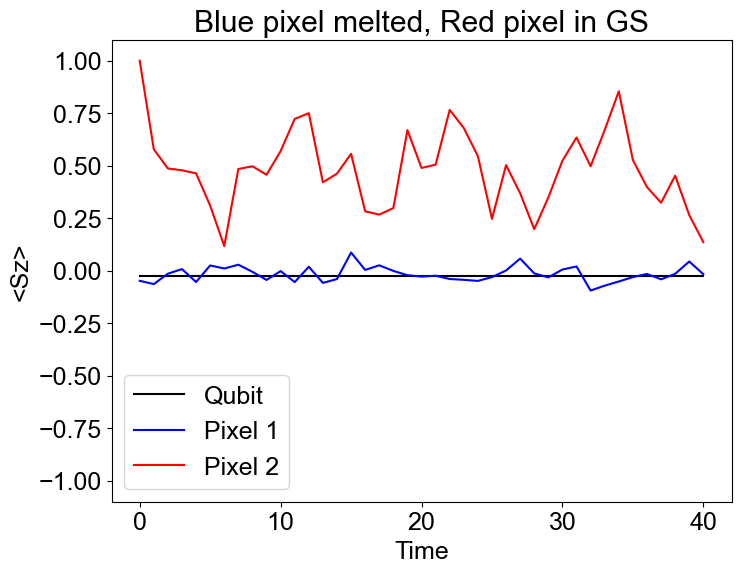

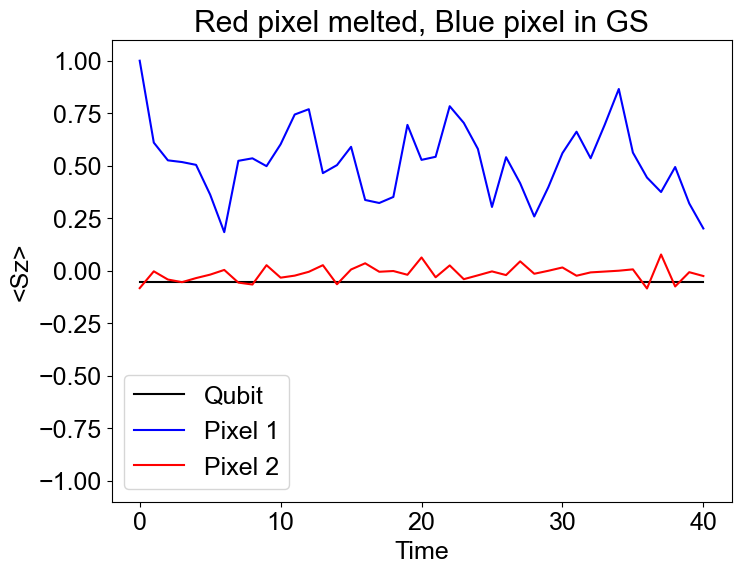

In [322]:
# Visualize time evolution of <Sz> for some states

# Blue pixel initially melted, red pixel in ground state
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(times, obs_time_blue[0]["Sz0"], label="Qubit", color="black")
ax.plot(times, obs_time_blue[0]["Sz1"], label="Pixel 1", color="blue")
ax.plot(times, obs_time_blue[0]["Sz2"], label="Pixel 2", color="red")
ax.set_ylim(-1.1, 1.1)
ax.set_xlabel("Time")
ax.set_ylabel("<Sz>")
ax.legend()
ax.set_title("Blue pixel melted, Red pixel in GS")
plt.show()

# Red pixel initially melted, blue pixel in ground state
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(times, obs_time_red[0]["Sz0"], label="Qubit", color="black")
ax.plot(times, obs_time_red[0]["Sz1"], label="Pixel 1", color="blue")
ax.plot(times, obs_time_red[0]["Sz2"], label="Pixel 2", color="red")
ax.set_ylim(-1.1, 1.1)
ax.set_xlabel("Time")
ax.set_ylabel("<Sz>")
ax.legend()
ax.set_title("Red pixel melted, Blue pixel in GS")
plt.show()

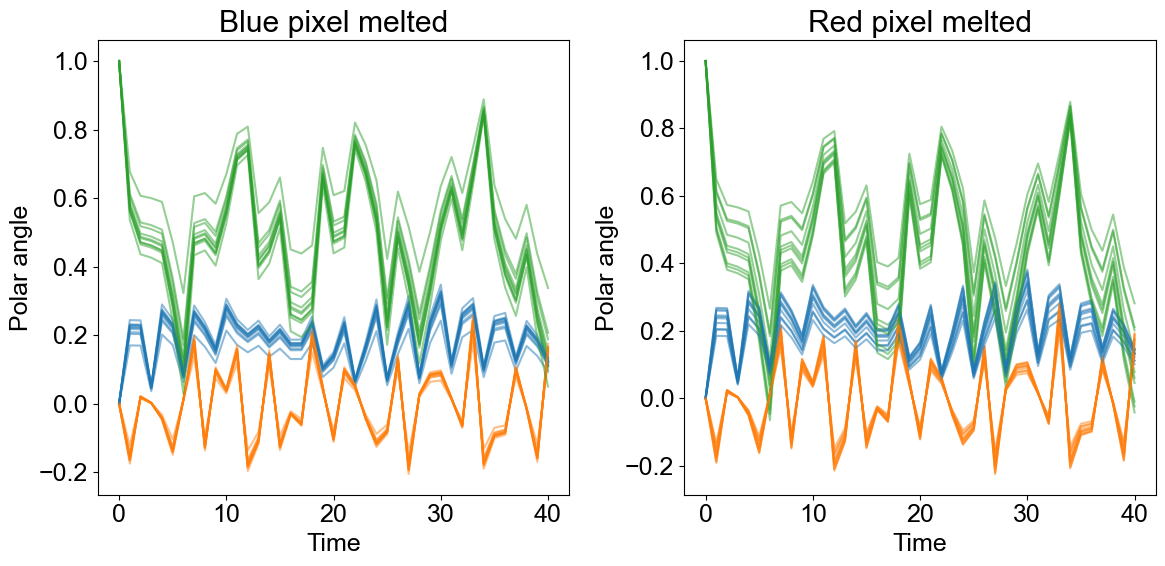

In [321]:
# Compare Sx, Sy, Sz projections of the various realizations
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Qubit initially in |1>, blue pixel melted
for realization in obs_time_blue:
    axs[0].plot(times, realization["Sx2"], color="C0", alpha=0.5)
    axs[0].plot(times, realization["Sy2"], color="C1", alpha=0.5)
    axs[0].plot(times, realization["Sz2"], color="C2", alpha=0.5)
    # axs[0].plot(times, np.arctan2(realization["Sy2"], realization["Sx2"]) / np.pi, color="C0", alpha=0.5)
    # purity = np.sqrt(realization["Sz2"] ** 2 + realization["Sx2"] ** 2 + realization["Sy2"] ** 2)
    # axs[0].plot(times, realization["Sz2"] / purity, color="C0", alpha=0.5)
axs[0].set_xlabel("Time")
axs[0].set_ylabel("Polar angle")
axs[0].set_title("Blue pixel melted")
# axs[0].legend(["$\langle\sigma_x^0\\rangle$", "$\langle\sigma_y^0\\rangle$", "$\langle\sigma_z^0\\rangle$"])

# Qubit initially in |0>, red pixel melted
for realization in obs_time_red:
    axs[1].plot(times, realization["Sx1"], color="C0", alpha=0.5)
    axs[1].plot(times, realization["Sy1"], color="C1", alpha=0.5)
    axs[1].plot(times, realization["Sz1"], color="C2", alpha=0.5)
    # axs[1].plot(times, np.arctan2(realization["Sy1"], realization["Sx1"]) / np.pi, color="C3", alpha=0.5)
    # purity = np.sqrt(realization["Sz1"] ** 2 + realization["Sx1"] ** 2 + realization["Sy1"] ** 2)
    # axs[1].plot(times, realization["Sz1"] / purity, color="C3", alpha=0.5)
axs[1].set_xlabel("Time")
axs[1].set_ylabel("Polar angle")
axs[1].set_title("Red pixel melted")
# axs[1].legend(["$\langle\sigma_x^0\\rangle$", "$\langle\sigma_y^0\\rangle$", "$\langle\sigma_z^0\\rangle$"])

plt.tight_layout()
plt.show()

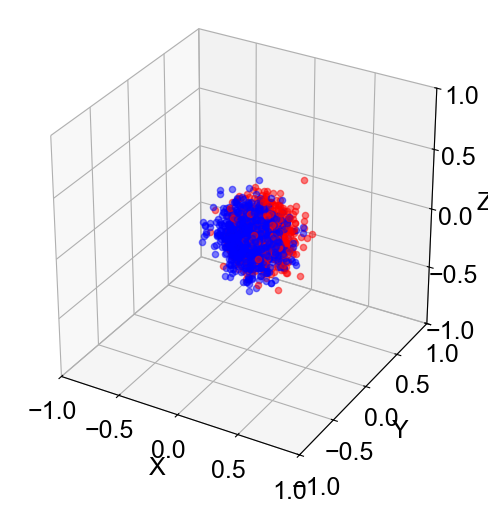

In [72]:
# Plot time evolution of <Sx>, <Sy>, <Sz> on the Bloch sphere
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

# Plot the Bloch sphere
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

# Plot the trajectory of the qubit state on the Bloch sphere
for realization in obs_time_blue[::10]:
    purity = np.sqrt(realization["Sx0"] ** 2 + realization["Sy0"] ** 2 + realization["Sz0"] ** 2)
    Sx_norm = realization["Sx0"] / purity
    Sy_norm = realization["Sy0"] / purity
    Sz_norm = realization["Sz0"] / purity
    # ax.scatter(Sx_norm, Sy_norm, Sz_norm, color="blue", alpha=0.5)
    ax.scatter(realization["Sx0"], realization["Sy0"], realization["Sz0"], color="blue", alpha=0.5)
    # ax.plot(Sx_norm, Sy_norm, Sz_norm, color="blue", alpha=0.5)
    # ax.plot(realization["Sx0"], realization["Sy0"], realization["Sz0"], color="blue", alpha=0.5)
for realization in obs_time_red[::10]:
    purity = np.sqrt(realization["Sx0"] ** 2 + realization["Sy0"] ** 2 + realization["Sz0"] ** 2)
    Sx_norm = realization["Sx0"] / purity
    Sy_norm = realization["Sy0"] / purity
    Sz_norm = realization["Sz0"] / purity
    # ax.scatter(Sx_norm, Sy_norm, Sz_norm, color="red", alpha=0.5)
    ax.scatter(realization["Sx0"], realization["Sy0"], realization["Sz0"], color="red", alpha=0.5)
    # ax.plot(Sx_norm, Sy_norm, Sz_norm, color="red", alpha=0.5)
    # ax.plot(realization["Sx0"], realization["Sy0"], realization["Sz0"], color="red", alpha=0.5)

# Set the limits and aspect ratio
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_box_aspect([1, 1, 1])  # Equal aspect ratio

plt.show()

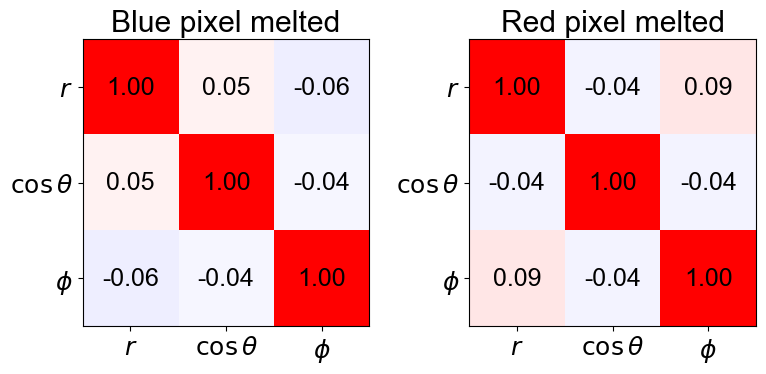

In [73]:
# Extract Bloch ball coordinate values (r,theta,phi) for the final qubit states
def get_bloch_sphere_coordinates(x, y, z):
    r = np.sqrt(x ** 2 + y ** 2 + z ** 2)
    u = z / r  # cos(theta)
    phi = np.arctan2(y, x)
    return r, u, phi

# Unpack Sx, Sy, Sz values
Sx_blue = np.array([realization["Sx0"][0] for realization in obs_time_blue])
Sy_blue = np.array([realization["Sy0"][0] for realization in obs_time_blue])
Sz_blue = np.array([realization["Sz0"][0] for realization in obs_time_blue])
Sx_red = np.array([realization["Sx0"][0] for realization in obs_time_red])
Sy_red = np.array([realization["Sy0"][0] for realization in obs_time_red])
Sz_red = np.array([realization["Sz0"][0] for realization in obs_time_red])

# Get Bloch sphere coordinates for blue and red pixel melted states
r_blue, u_blue, phi_blue = get_bloch_sphere_coordinates(Sx_blue, Sy_blue, Sz_blue)
r_red, u_red, phi_red = get_bloch_sphere_coordinates(Sx_red, Sy_red, Sz_red)
coord_blue = np.array([r_blue, u_blue, phi_blue])
coord_red = np.array([r_red, u_red, phi_red])

# Get correlation matrix of (r,u,phi)
corr_blue = np.corrcoef(coord_blue)
corr_red = np.corrcoef(coord_red)

# Visualize correlation matrices
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(corr_blue, cmap="bwr", vmin=-1, vmax=1)
axs[0].set_title("Blue pixel melted")
axs[1].imshow(corr_red, cmap="bwr", vmin=-1, vmax=1)
axs[1].set_title("Red pixel melted")
for ax in axs:
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["$r$", "$\cos\\theta$", "$\phi$"])
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(["$r$", "$\cos\\theta$", "$\phi$"])

    # Add annotations
    for i in range(3):
        for j in range(3):
            current_corr = corr_blue if ax == axs[0] else corr_red
            ax.text(j, i, f"{current_corr[i, j]:.2f}", ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

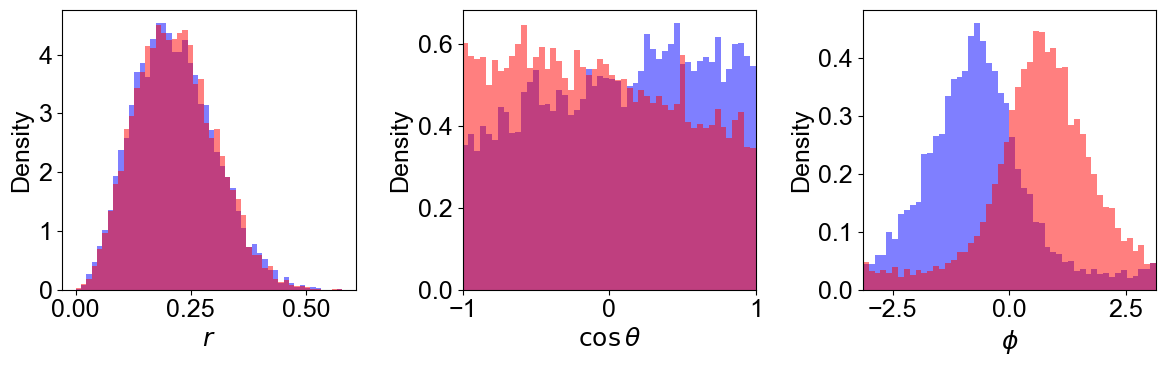

In [74]:
# Plot marginal distributions of r, cos(theta) and phi
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
n_bins = 50

# Marginal distribution or r
bins_r = np.linspace(0, np.max(coord_blue[0]), n_bins + 1)
hist_r_blue, bins_r_blue, _ = axs[0].hist(coord_blue[0], bins=bins_r, density=True, color="blue", alpha=0.5)
hist_r_red, bins_r_red, _ = axs[0].hist(coord_red[0], bins=bins_r, density=True, color="red", alpha=0.5)
axs[0].set_xlabel("$r$")
axs[0].set_ylabel("Density")

# Marginal distribution of cos(theta)
bins_u = np.linspace(-1, 1, n_bins + 1)
hist_u_blue, bins_u_blue, _ = axs[1].hist(coord_blue[1], bins=bins_u, density=True, color="blue", alpha=0.5)
hist_u_red, bins_u_red, _ = axs[1].hist(coord_red[1], bins=bins_u, density=True, color="red", alpha=0.5)
axs[1].set_xlim(-1, 1)
axs[1].set_xlabel("$\cos\\theta$")
axs[1].set_ylabel("Density")

# Marginal distribution of phi
bins_phi = np.linspace(-np.pi, np.pi, n_bins + 1)
hist_phi_blue, bins_phi_blue, _ = axs[2].hist(coord_blue[2], bins=bins_phi, density=True, color="blue", alpha=0.5)
hist_phi_red, bins_phi_red, _ = axs[2].hist(coord_red[2], bins=bins_phi, density=True, color="red", alpha=0.5)
axs[2].set_xlim(-np.pi, np.pi)
axs[2].set_xlabel("$\phi$")
axs[2].set_ylabel("Density")

plt.tight_layout()
plt.show()


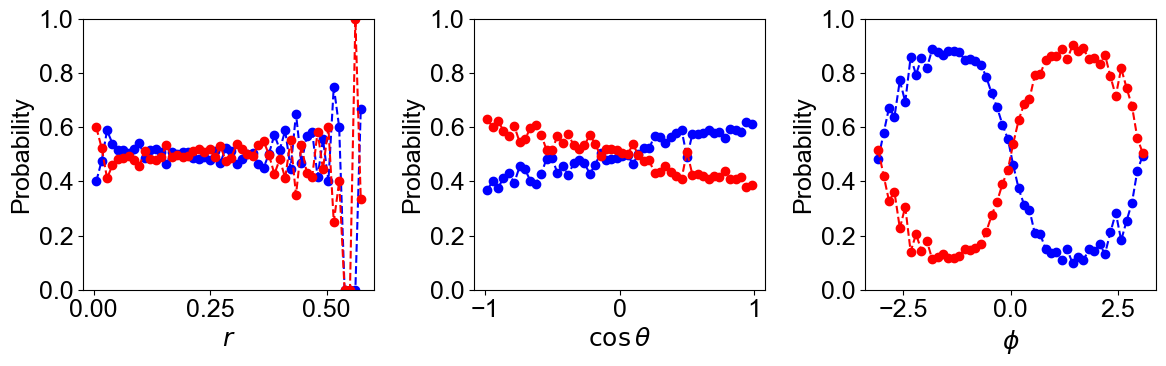

In [75]:
# Compute posterior probabilities of each pixel melting via Bayes' theorem
eps = 1e-12  # Small value to avoid division by zero

rs = (bins_r[1:] + bins_r[:-1]) / 2
us = (bins_u[1:] + bins_u[:-1]) / 2
phis = (bins_phi[1:] + bins_phi[:-1]) / 2

prob_r_blue = hist_r_blue / (hist_r_blue + hist_r_red + eps)
prob_r_red = hist_r_red / (hist_r_blue + hist_r_red + eps)
prob_u_blue = hist_u_blue / (hist_u_blue + hist_u_red + eps)
prob_u_red = hist_u_red / (hist_u_blue + hist_u_red + eps)
prob_phi_blue = hist_phi_blue / (hist_phi_blue + hist_phi_red + eps)
prob_phi_red = hist_phi_red / (hist_phi_blue + hist_phi_red + eps)

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].plot(rs, prob_r_blue, color="blue", linestyle="--", marker="o", label="Blue melted")
axs[0].plot(rs, prob_r_red, color="red",  linestyle="--", marker="o", label="Red melted")
axs[0].set_ylim(0, 1)
axs[0].set_xlabel("$r$")
axs[0].set_ylabel("Probability")

axs[1].plot(us, prob_u_blue, color="blue", linestyle="--", marker="o", label="Blue melted")
axs[1].plot(us, prob_u_red, color="red", linestyle="--", marker="o", label="Red melted")
axs[1].set_ylim(0, 1)
axs[1].set_xlabel("$\cos\\theta$")
axs[1].set_ylabel("Probability")

axs[2].plot(phis, prob_phi_blue, color="blue", linestyle="--", marker="o", label="Blue melted")
axs[2].plot(phis, prob_phi_red, color="red", linestyle="--", marker="o", label="Red melted")
axs[2].set_ylim(0, 1)
axs[2].set_xlabel("$\phi$")
axs[2].set_ylabel("Probability")

plt.tight_layout()
plt.show()

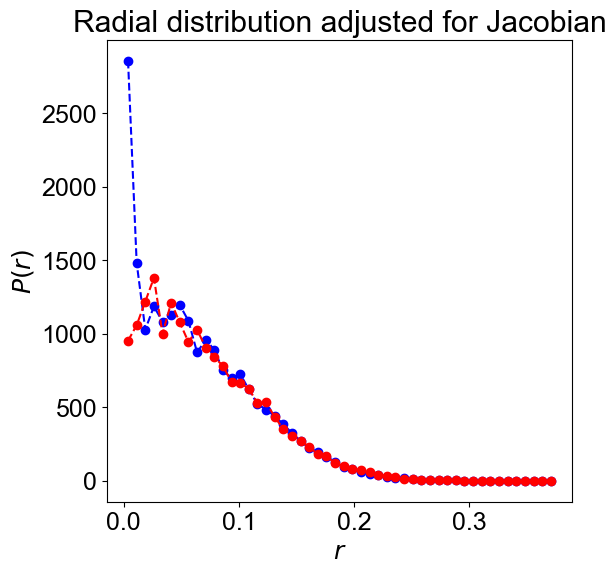

In [65]:
# Plot radial distribution adjusted for Jacobian
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.plot(rs, hist_r_blue / rs ** 2, color="blue", linestyle="--", marker="o")
ax.plot(rs, hist_r_red / rs ** 2, color="red", linestyle="--", marker="o")
ax.set_xlabel("$r$")
ax.set_ylabel("$P(r)$")
ax.set_title("Radial distribution adjusted for Jacobian")
plt.show()

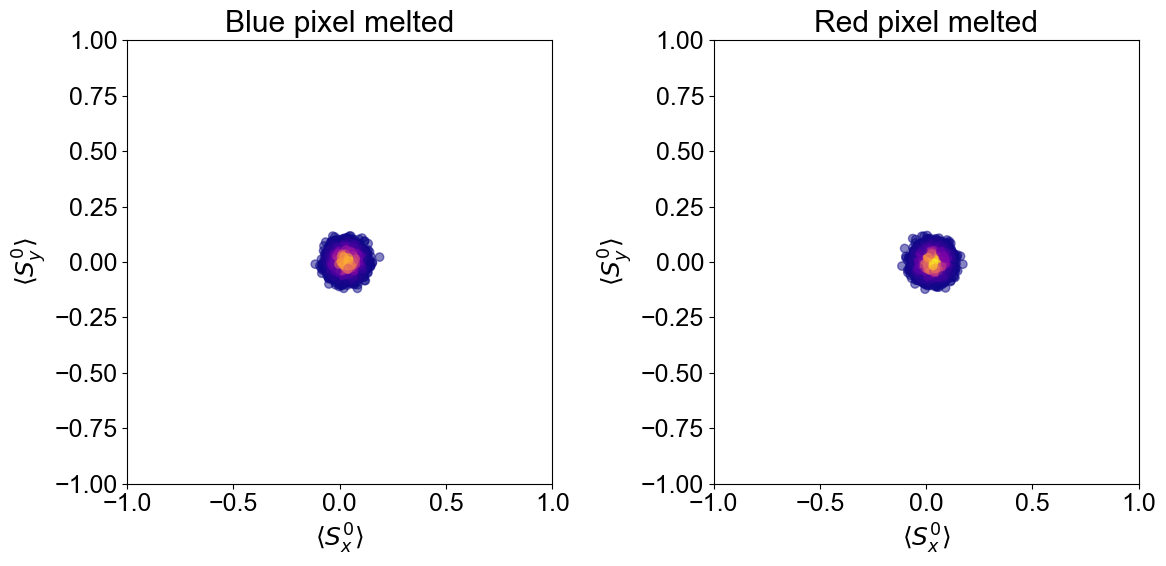

In [36]:
# Plot distribution of the transverse magnetization (Sx,Sy)
xy_blue = np.vstack((Sx_blue, Sy_blue))
z_kde_blue = gaussian_kde(xy_blue)(xy_blue)
xy_red = np.vstack((Sx_red, Sy_red))
z_kde_red = gaussian_kde(xy_red)(xy_red)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].scatter(Sx_blue, Sy_blue, c=z_kde_blue, cmap="plasma", alpha=0.5)
axs[0].set_xlim(-1, 1)
axs[0].set_ylim(-1, 1)
axs[0].set_xlabel("$\langle S_x^0 \\rangle$")
axs[0].set_ylabel("$\langle S_y^0 \\rangle$")
axs[0].set_title("Blue pixel melted")

axs[1].scatter(Sx_red, Sy_red, c=z_kde_red, cmap="plasma", alpha=0.5)
axs[1].set_xlim(-1, 1)
axs[1].set_ylim(-1, 1)
axs[1].set_xlabel("$\langle S_x^0 \\rangle$")
axs[1].set_ylabel("$\langle S_y^0 \\rangle$")
axs[1].set_title("Red pixel melted")
plt.tight_layout()
plt.show()

In [ ]:
z_kde_red

array([1.02201548, 0.81380411, 1.04891061, ..., 0.21951858, 0.29292619,
       1.03445916])

In [76]:
# System parameters
N_pixel = 5  # Number of spins per pixel
N_total = 2 * N_pixel + 1  # 2 pixels + single qubit
Jzz = 1.0  # zz interaction strength
hx = 1.3  # x field strength
hz = 0.3  # z field strength

# Create spin basis as follows:
# - Qubit to measure: 0
# - 1st pixel: 1,...,N_pixel
# - 2nd pixel: N_pixel+1,...,2*N_pixel
basis = spin_basis_1d(N_total, pauli=True)
print(basis)

# Define site-coupling lists
# Free Hamiltonian of each pixel (open BC)
H1 = [[Jzz, i, i + 1] for i in range(1, N_pixel)]
H2 = [[Jzz, i, i + 1] for i in range(N_pixel + 1, N_total - 1)]

# Interaction Hamiltonian
Hint_xz = [[hz, 0, i] for i in range(1, N_total)]
Hint_zx1 = [[hx / 2, 0, i] for i in range(1, N_pixel + 1)]
Hint_zx2 = [[-hx / 2, 0, i] for i in range(N_pixel + 1, N_total)]
Hext_x = [[hx / 2, i] for i in range(1, N_total)]

# Define total Hamiltonian
static = [["zz", H1], ["zz", H2], ["xz", Hint_xz], ["zx", Hint_zx1], ["zx", Hint_zx2], ["x", Hext_x]]
H = hamiltonian(static, [], basis=basis, dtype=np.float64)

reference states: 
array index   /   Fock state   /   integer repr. 
    0.  |1 1 1 1 1 1 1 1 1 1 1>  2047 
    1.  |1 1 1 1 1 1 1 1 1 1 0>  2046 
    2.  |1 1 1 1 1 1 1 1 1 0 1>  2045 
    3.  |1 1 1 1 1 1 1 1 1 0 0>  2044 
    4.  |1 1 1 1 1 1 1 1 0 1 1>  2043 
    5.  |1 1 1 1 1 1 1 1 0 1 0>  2042 
    6.  |1 1 1 1 1 1 1 1 0 0 1>  2041 
    7.  |1 1 1 1 1 1 1 1 0 0 0>  2040 
    8.  |1 1 1 1 1 1 1 0 1 1 1>  2039 
    9.  |1 1 1 1 1 1 1 0 1 1 0>  2038 
   10.  |1 1 1 1 1 1 1 0 1 0 1>  2037 
   11.  |1 1 1 1 1 1 1 0 1 0 0>  2036 
   12.  |1 1 1 1 1 1 1 0 0 1 1>  2035 
   13.  |1 1 1 1 1 1 1 0 0 1 0>  2034 
   14.  |1 1 1 1 1 1 1 0 0 0 1>  2033 
   15.  |1 1 1 1 1 1 1 0 0 0 0>  2032 
   16.  |1 1 1 1 1 1 0 1 1 1 1>  2031 
   17.  |1 1 1 1 1 1 0 1 1 1 0>  2030 
   18.  |1 1 1 1 1 1 0 1 1 0 1>  2029 
   19.  |1 1 1 1 1 1 0 1 1 0 0>  2028 
   20.  |1 1 1 1 1 1 0 1 0 1 1>  2027 
   21.  |1 1 1 1 1 1 0 1 0 1 0>  2026 
   22.  |1 1 1 1 1 1 0 1 0 0 1>  2025 
   23.  |1 1 1 1 1 1 0 1 0 0 0>  2

In [252]:
# System parameters
N_bath = 8  # Number of spins in bath
N_total = N_bath + 1  # Qubit + bath
J = 1. # Qubit-bath interaction strength
h = 10. # Bath field strength

# Create spin basis as follows:
# - Qubit: 0
# - Bath: 1,...,N_bath
basis = spin_basis_1d(N_total, pauli=True)

# Define site-coupling lists
# Free Hamiltonian of bath (open BC)
Hbath = [[Jzz, i, i + 1] for i in range(1, N_bath)]
Hfield = [[h, i] for i in range(1, N_bath)]

# Qubit-bath interaction Hamiltonian
Hint = [[J, 0, i] for i in range(1, N_total)]

# Define total Hamiltonian
static = [["zz", Hbath], ["z", Hfield], ["x", Hfield], ["+-", Hint], ["-+", Hint], ["zz", Hint]]
H = hamiltonian(static, [], basis=basis, dtype=np.float64)

Hermiticity check passed!
Symmetry checks passed!


In [253]:
# Perform exact diagonalization
E, V = H.eigh()
print("Exact diagonalization completed!")

Exact diagonalization completed!


In [254]:
# Add small noise to eigenvalues to avoid degeneracy
E_noise = E + 0*np.random.normal(0, 1e-6, size=E.shape)
E_noise = np.sort(E_noise)  # Sort eigenvalues after adding noise

# Compute mean level spacing
mean_spacing = mean_level_spacing(E_noise)
print(f"Mean level spacing: {mean_spacing:.6f}")

Mean level spacing: 0.489745


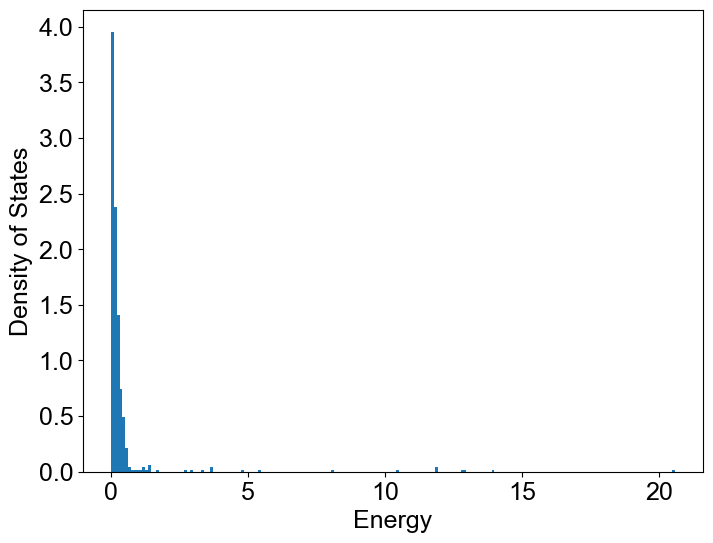

In [255]:
# Visualize density of states
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.hist(np.diff(E), bins=200, density=True)
ax.set_xlabel("Energy")
ax.set_ylabel("Density of States")
plt.show()

In [256]:
# Compute bipartite entanglement entropy between the two pixels
# subsys_pixel1 = list(range(1, N_pixel + 1))
# subsys_pixel1 = list(range(1, N_tota // 2))
Sent_eigs = []
for i in tqdm(range(len(E))):
    # Compute the entanglement entropy for each eigenstate
    # Sent_eigs.append(basis.ent_entropy(
    #     V[:, i], sub_sys_A=subsys_pixel1, density=False)["Sent_A"])
    Sent_eigs.append(basis.ent_entropy(
        V[:, i], density=False)["Sent_A"])

100%|██████████| 512/512 [00:00<00:00, 1655.95it/s]


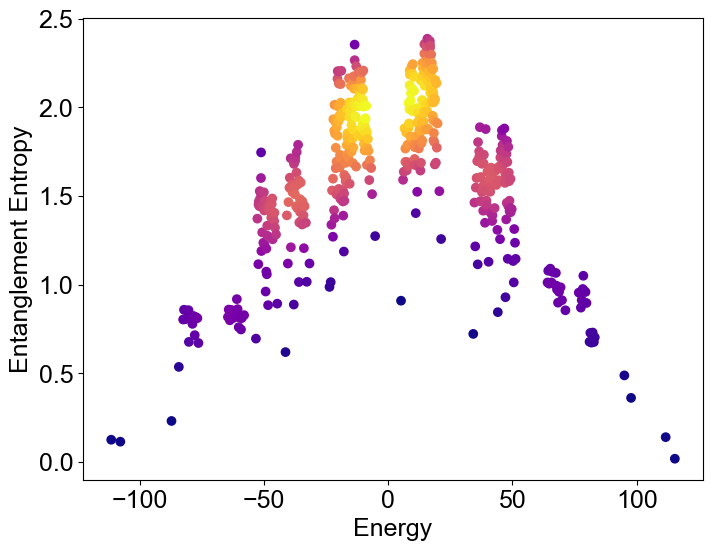

In [257]:
# Visualize the entanglement entropy
ES_kde = np.vstack((E, Sent_eigs))
z_kde = gaussian_kde(ES_kde)(ES_kde)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.scatter(E, Sent_eigs, c=z_kde, cmap="plasma")
ax.set_xlabel("Energy")
ax.set_ylabel("Entanglement Entropy")
plt.show()

In [258]:
# Check if ETH holds by computing the expectation value of a single spin in each pixel
# sx1 = quantum_LinearOperator([["x", [[1, 1]]]], basis=basis, dtype=np.float64)
# sx2 = quantum_LinearOperator([["x", [[1, N_pixel + 1]]]], basis=basis, dtype=np.float64)
sx = quantum_LinearOperator([["x", [[1, N_bath // 2]]]], basis=basis, dtype=np.float64)

# sx1_expt_eigs, sx2_expt_eigs = [], []
sx_expt_eigs = []
for i in tqdm(range(len(E))):
    # Compute the expectation value of sx for each eigenstate
    # sx1_expt_eigs.append(sx1.expt_value(V[:, i]))
    # sx2_expt_eigs.append(sx2.expt_value(V[:, i]))
    sx_expt_eigs.append(sx.expt_value(V[:, i]))

Hermiticity check passed!
Symmetry checks passed!


100%|██████████| 512/512 [00:00<00:00, 2479.36it/s]


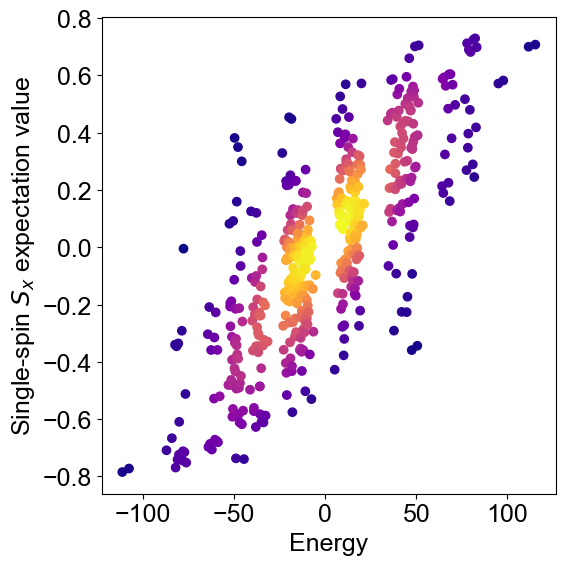

In [259]:
# Visualize the expectation values
Esx_kde = np.vstack((E, sx_expt_eigs))
z_sx_kde = gaussian_kde(Esx_kde)(Esx_kde)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(E, sx_expt_eigs, c=z_sx_kde, cmap="plasma")
ax.set_xlabel("Energy")
ax.set_ylabel("Single-spin $S_x$ expectation value")

plt.tight_layout()
plt.show()

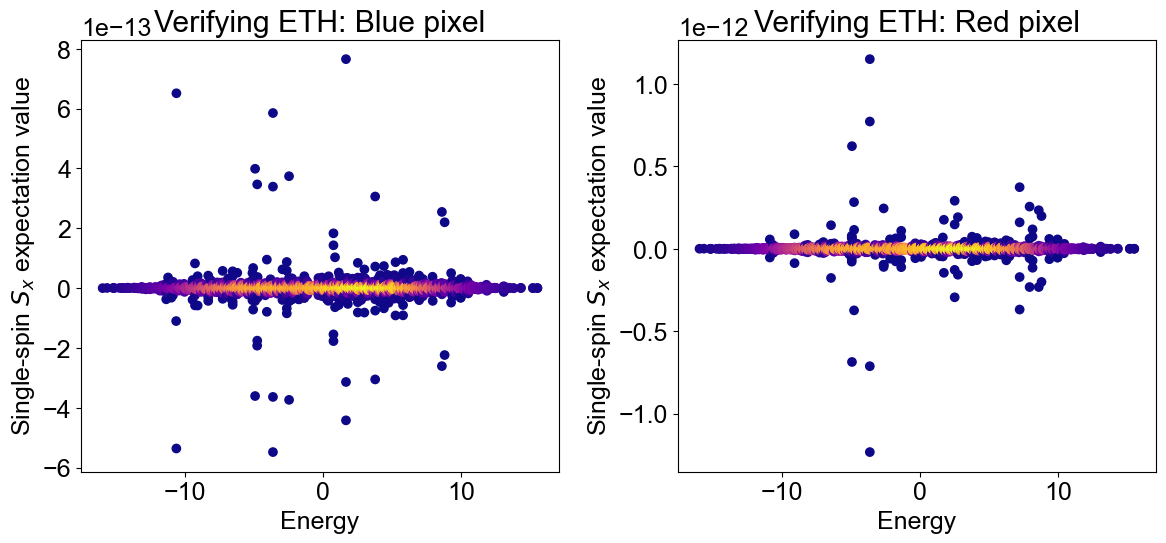

In [133]:
# Visualize the expectation values
Esx1_kde = np.vstack((E, sx1_expt_eigs))
Esx2_kde = np.vstack((E, sx2_expt_eigs))
z_sx1_kde = gaussian_kde(Esx1_kde)(Esx1_kde)
z_sx2_kde = gaussian_kde(Esx2_kde)(Esx2_kde)
z_kde = gaussian_kde(ES_kde)(ES_kde)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].scatter(E, sx1_expt_eigs, c=z_sx1_kde, cmap="plasma")
axs[1].scatter(E, sx2_expt_eigs, c=z_sx2_kde, cmap="plasma")
axs[0].set_title("Verifying ETH: Blue pixel")
axs[1].set_title("Verifying ETH: Red pixel")

for ax in axs:
    ax.set_xlabel("Energy")
    ax.set_ylabel("Single-spin $S_x$ expectation value")

plt.tight_layout()
plt.show()

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!


C:\Users\matan\AppData\Local\Programs\Python\Python39\lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\matan\AppData\Local\Programs\Python\Python39\lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


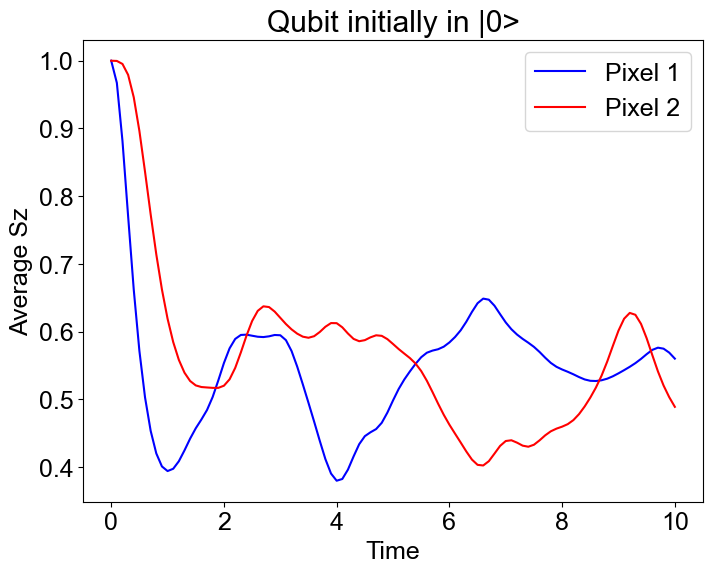

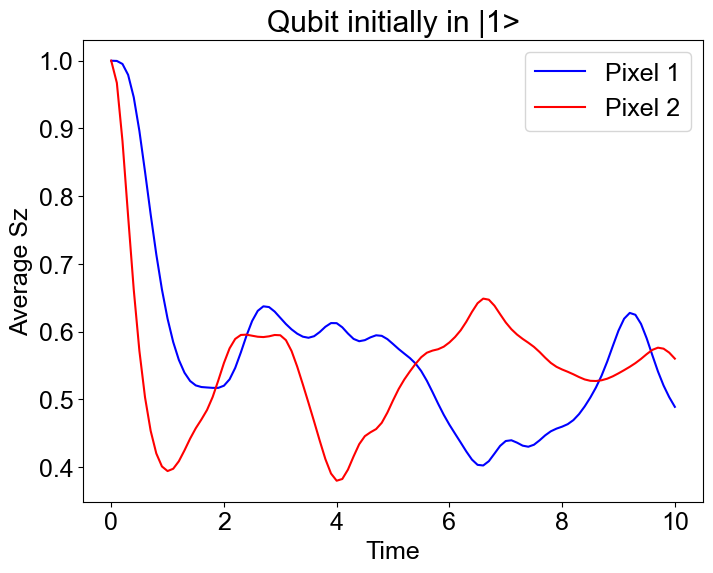

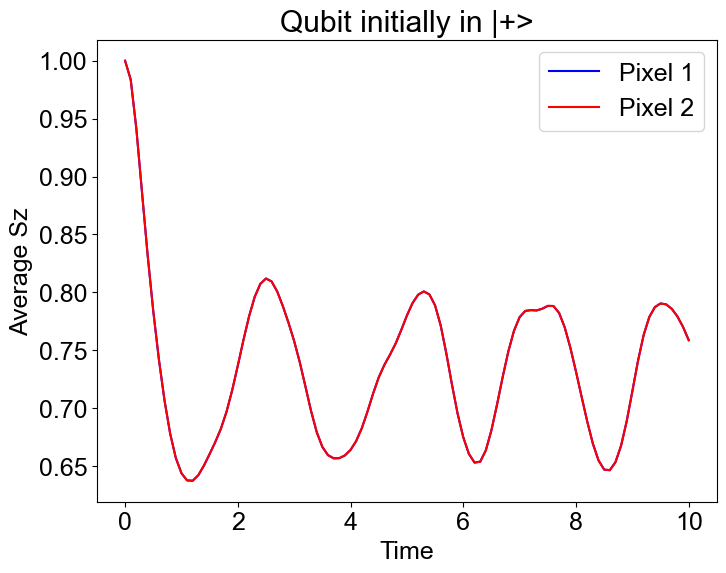

In [ ]:
# Compute time-dependence of average Sz int each pixel for various initial states

# Average Sz observables
Sz1 = hamiltonian([["z", [[1 / N_pixel, i] for i in range(1, N_pixel + 1)]]], [],
                  basis=basis, dtype=np.float64)
Sz2 = hamiltonian([["z", [[1 / N_pixel, i] for i in range(N_pixel + 1, N_total)]]], [],
                  basis=basis, dtype=np.float64)

times = np.linspace(0, 10, 101)

# Qubit in |0>
psi0 = np.zeros(basis.Ns, dtype=np.complex128)
psi0[0] = 1.
obs_time = obs_vs_time(psi_t=(psi0, E, V), Obs_dict={"Sz1": Sz1, "Sz2": Sz2}, times=times)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(times, obs_time["Sz1"], label="Pixel 1", color="blue")
ax.plot(times, obs_time["Sz2"], label="Pixel 2", color="red")
ax.set_xlabel("Time")
ax.set_ylabel("Average Sz")
ax.legend()
ax.set_title("Qubit initially in |0>")
plt.show()

# Qubit in |1>
psi0 = np.zeros(basis.Ns, dtype=np.complex128)
psi0[1024] = 1.
obs_time = obs_vs_time(psi_t=(psi0, E, V), Obs_dict={"Sz1": Sz1, "Sz2": Sz2}, times=times)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(times, obs_time["Sz1"], label="Pixel 1", color="blue")
ax.plot(times, obs_time["Sz2"], label="Pixel 2", color="red")
ax.set_xlabel("Time")
ax.set_ylabel("Average Sz")
ax.legend()
ax.set_title("Qubit initially in |1>")
plt.show()

# Qubit in |+>
psi0 = np.zeros(basis.Ns, dtype=np.complex128)
psi0[0] = 1. / np.sqrt(2)
psi0[1024] = 1. / np.sqrt(2)
obs_time = obs_vs_time(psi_t=(psi0, E, V), Obs_dict={"Sz1": Sz1, "Sz2": Sz2}, times=times)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(times, obs_time["Sz1"], label="Pixel 1", color="blue")
ax.plot(times, obs_time["Sz2"], label="Pixel 2", color="red")
ax.set_xlabel("Time")
ax.set_ylabel("Average Sz")
ax.legend()
ax.set_title("Qubit initially in |+>")
plt.show()